# **Week 7 – Outlier Detection and Data Quality**

goal : 
- Flag and/or remove outliers: price, price per square footage, close to list ratio, or days on market 

### Set Up

In [1]:
from pathlib import Path
from datetime import datetime
import re
import pandas as pd
import os
import numpy as np

DATA_DIR = Path("/Users/kmaxx/Desktop/IDX-da/idx_data")

sold_df = pd.read_csv(DATA_DIR / "featured_sold.csv", low_memory= False)
listing_df = pd.read_csv(DATA_DIR / "featured_listing.csv", low_memory= False)

### Outlier Detection

In [8]:
import pandas as pd

outlier_columns = [
    "ClosePrice",
    "LivingArea",
    "DaysOnMarket"
]

sold_flagged_df = sold_df.copy()
sold_flagged_df[outlier_columns] = sold_flagged_df[outlier_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

outlier_flag_columns = []

for column in outlier_columns:
    q1 = sold_flagged_df[column].quantile(0.25)
    q3 = sold_flagged_df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flag_column = f"{column}_Outlier"
    outlier_flag_columns.append(flag_column)

    sold_flagged_df[flag_column] = (
        sold_flagged_df[column].notna()
        & ~sold_flagged_df[column].between(lower_bound, upper_bound)
    )

    print(
        f"{column}: "
        f"{sold_flagged_df[flag_column].sum():,} outliers | "
        f"bounds: {lower_bound:,.2f} to {upper_bound:,.2f}"
    )

sold_flagged_df["AnyOutlier"] = sold_flagged_df[
    outlier_flag_columns
].any(axis=1)

sold_no_outliers_df = sold_flagged_df.loc[
    ~sold_flagged_df["AnyOutlier"]
].copy()

print(f"\nOriginal rows: {len(sold_df):,}")
print(f"Flagged rows: {sold_flagged_df['AnyOutlier'].sum():,}")
print(f"Rows after removal: {len(sold_no_outliers_df):,}")

ClosePrice: 33,340 outliers | bounds: -512,500.00 to 2,387,500.00
LivingArea: 19,564 outliers | bounds: -216.00 to 3,688.00
DaysOnMarket: 34,103 outliers | bounds: -52.00 to 108.00

Original rows: 447,491
Flagged rows: 70,145
Rows after removal: 377,346


In [9]:
review_columns = [
    "ListingKey",
    "CountyOrParish",
    "PropertySubType",
    "ClosePrice",
    "LivingArea",
    "DaysOnMarket",
    "ClosePrice_Outlier",
    "LivingArea_Outlier",
    "DaysOnMarket_Outlier",
    "AnyOutlier"
]

display(
    sold_flagged_df.loc[
        sold_flagged_df["AnyOutlier"],
        review_columns
    ].head(10)
)

,ListingKey,CountyOrParish,PropertySubType,ClosePrice,LivingArea,DaysOnMarket,ClosePrice_Outlier,LivingArea_Outlier,DaysOnMarket_Outlier,AnyOutlier
2,492708527,San Diego,SingleFamilyResidence,725000.0,1716.0,254,False,False,True,True
12,1073198830,Riverside,SingleFamilyResidence,4700000.0,4185.0,21,True,True,False,True
16,1073168383,Orange,SingleFamilyResidence,5995000.0,2193.0,0,True,False,False,True
17,1073167963,Orange,Condominium,2570000.0,2428.0,0,True,False,False,True
21,1073162210,San Mateo,SingleFamilyResidence,4025000.0,3300.0,0,True,False,False,True
36,1073132731,Orange,SingleFamilyResidence,2100000.0,3907.0,0,False,True,False,True
37,1073132101,Orange,SingleFamilyResidence,2860000.0,3814.0,0,True,True,False,True
38,1073131282,Alameda,SingleFamilyResidence,2850000.0,1817.0,0,True,False,False,True
44,1073121739,Orange,SingleFamilyResidence,6300000.0,2543.0,0,True,False,False,True
45,1073121422,Santa Clara,SingleFamilyResidence,4000000.0,1646.0,0,True,False,False,True


### Engineer feature for sold

In [10]:
import pandas as pd

outlier_columns = [
    "ListPrice",
    "LivingArea",
    "DaysOnMarket"
]

listing_flagged_df = listing_df.copy()
listing_flagged_df[outlier_columns] = listing_flagged_df[outlier_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

outlier_flag_columns = []

for column in outlier_columns:
    q1 = listing_flagged_df[column].quantile(0.25)
    q3 = listing_flagged_df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    flag_column = f"{column}_Outlier"
    outlier_flag_columns.append(flag_column)

    listing_flagged_df[flag_column] = (
        listing_flagged_df[column].notna()
        & ~listing_flagged_df[column].between(
            lower_bound,
            upper_bound
        )
    )

    print(
        f"{column}: "
        f"{listing_flagged_df[flag_column].sum():,} outliers | "
        f"bounds: {lower_bound:,.2f} to {upper_bound:,.2f}"
    )

listing_flagged_df["AnyOutlier"] = listing_flagged_df[
    outlier_flag_columns
].any(axis=1)

listing_no_outliers_df = listing_flagged_df.loc[
    ~listing_flagged_df["AnyOutlier"]
].copy()

print(f"\nOriginal rows: {len(listing_df):,}")
print(f"Flagged rows: {listing_flagged_df['AnyOutlier'].sum():,}")
print(f"Rows after removal: {len(listing_no_outliers_df):,}")

ListPrice: 51,412 outliers | bounds: -617,750.00 to 2,578,650.00
LivingArea: 30,271 outliers | bounds: -334.50 to 3,885.50
DaysOnMarket: 49,574 outliers | bounds: -20.50 to 47.50

Original rows: 613,615
Flagged rows: 103,995
Rows after removal: 509,620


### Segment Analysis Continue

In [17]:
import pandas as pd

def create_segment_summary(df, group_columns):
    required_metrics = [
        "ClosePrice",
        "PriceRatio",
        "PricePerSqFt",
        "DaysOnMarket",
        "ListingToContractDays",
        "ContractToCloseDays"
    ]

    data = df.copy()

    for col in required_metrics:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    count_column = "ListingKey" if "ListingKey" in data.columns else "ClosePrice"

    summary = data.groupby(
        group_columns,
        dropna=False,
        observed=True
    ).agg(
        ListingCount=(count_column, "nunique"),
        AverageClosePrice=("ClosePrice", "mean"),
        AveragePriceRatio=("PriceRatio", "mean"),
        AveragePricePerSqFt=("PricePerSqFt", "mean"),
        AverageDaysOnMarket=("DaysOnMarket", "mean"),
        AverageListingToContractDays=("ListingToContractDays", "mean"),
        AverageContractToCloseDays=("ContractToCloseDays", "mean")
    ).reset_index()

    mean_columns = [
        col for col in summary.select_dtypes("number").columns
        if col != "ListingCount"
    ]

    summary[mean_columns] = summary[mean_columns].round(2)

    return summary.sort_values(["ListingCount", "AverageClosePrice"], ascending=[False, False]).reset_index(drop=True)

In [18]:
sold_no_outliers_df["DistrictStatus"] = sold_no_outliers_df[
    "DistrictName"
].notna().map({
    True: "With School District",
    False: "No District Match"
})

district_status_summary_no_outliers = create_segment_summary(
    sold_no_outliers_df,
    [
        "DistrictStatus",
        "PropertySubType"
    ]
)

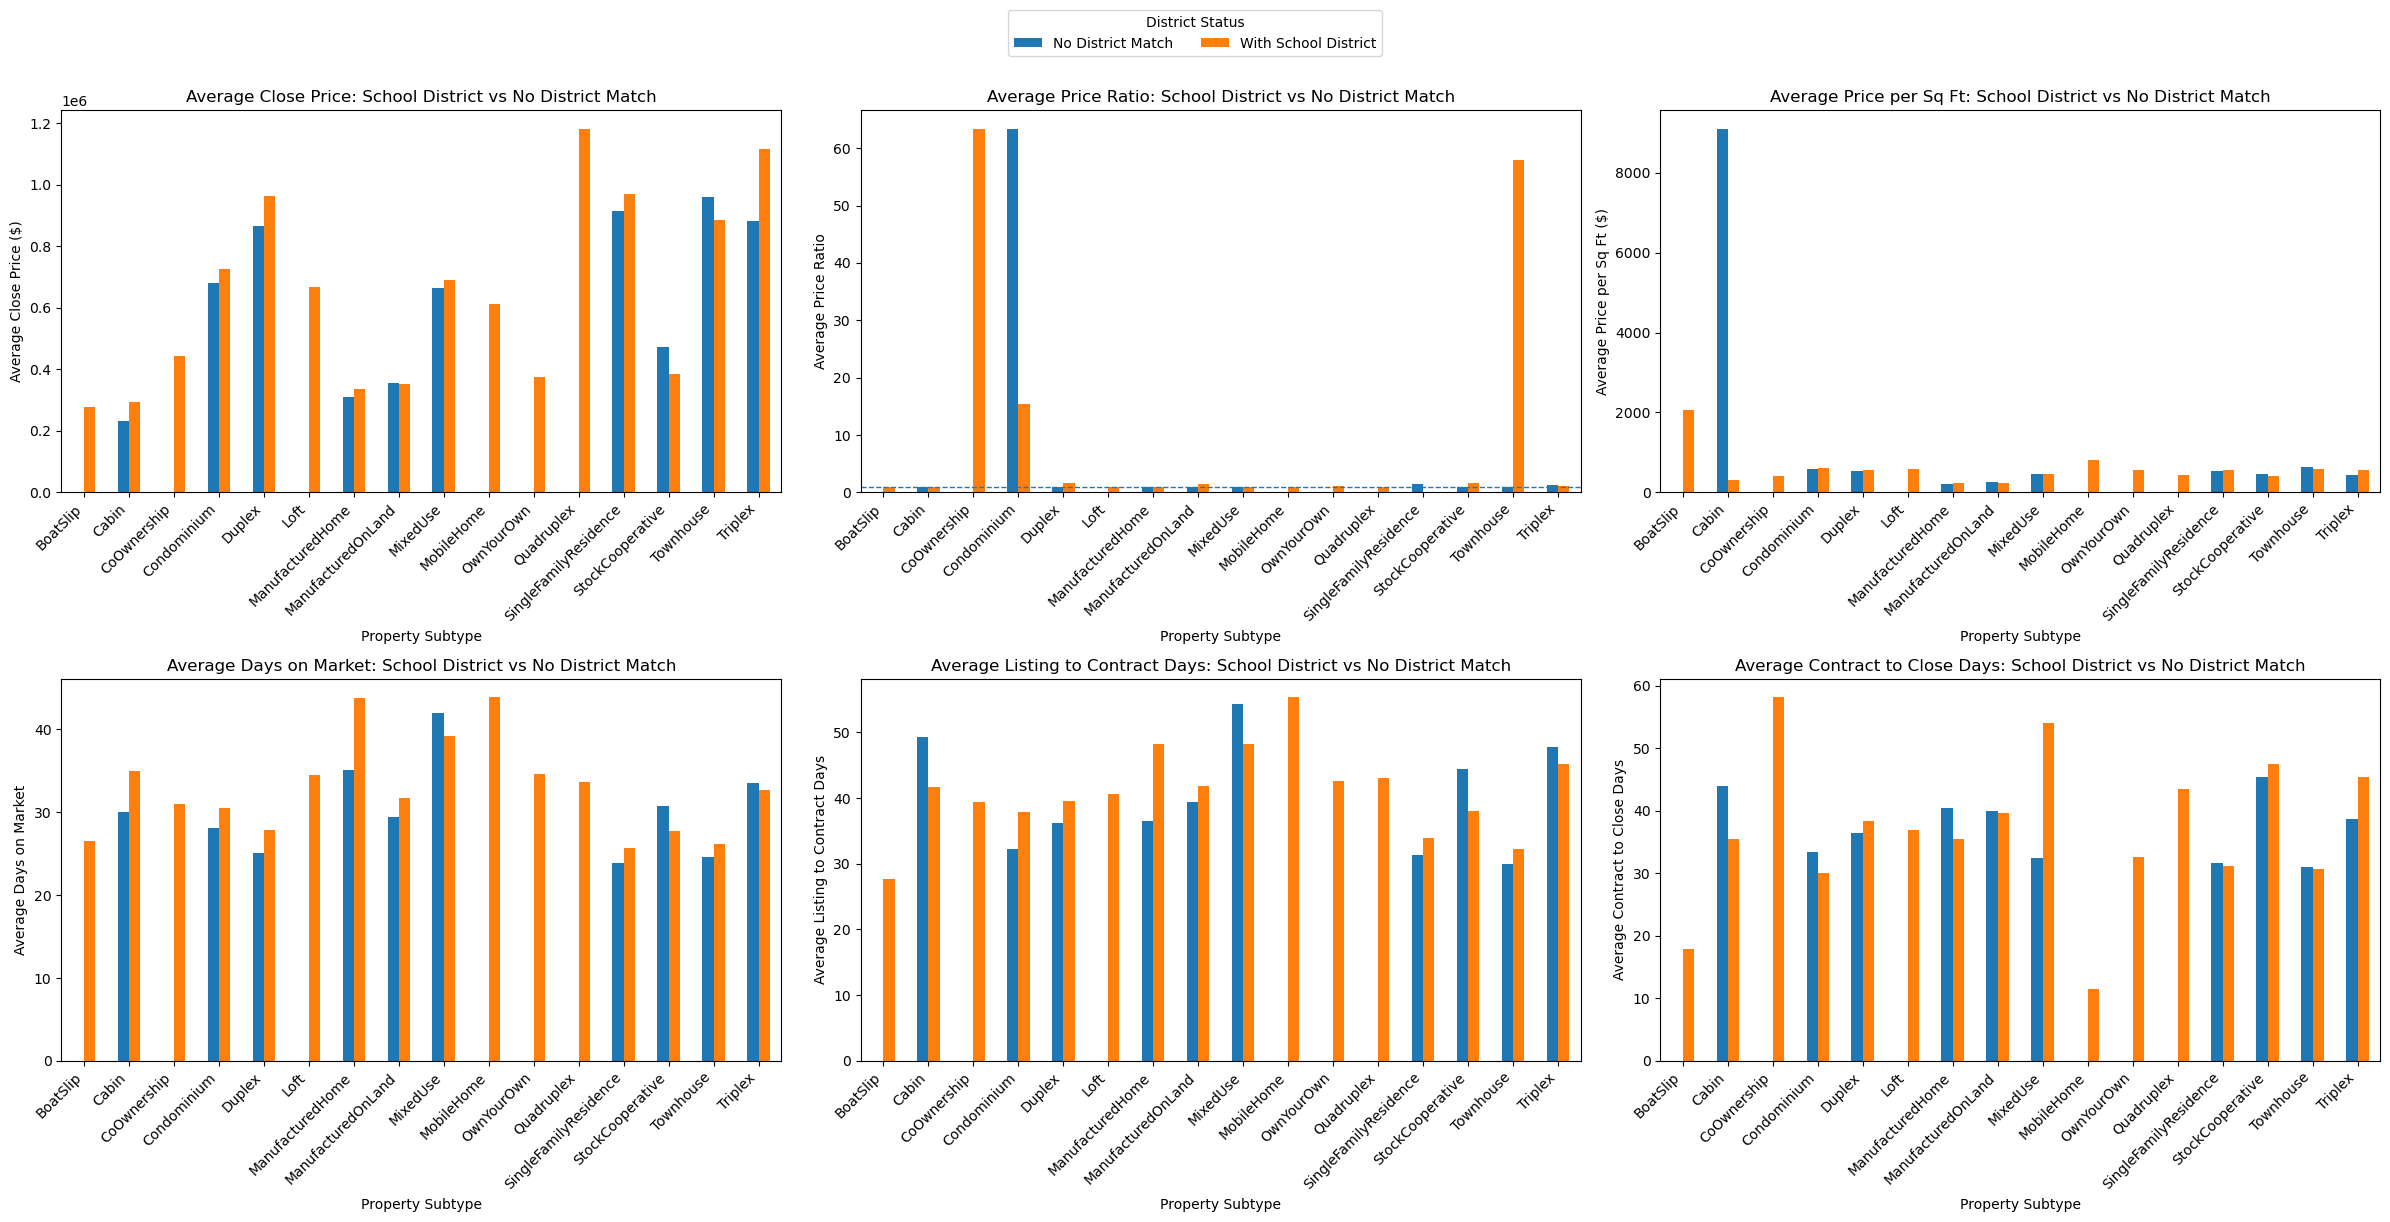

In [19]:
import matplotlib.pyplot as plt

minimum_listings = 10

plot_data = district_status_summary_no_outliers.loc[
    district_status_summary_no_outliers["PropertySubType"].notna()
    & (district_status_summary_no_outliers["ListingCount"] >= minimum_listings)
].copy()

metric_columns = [
    "AverageClosePrice",
    "AveragePriceRatio",
    "AveragePricePerSqFt",
    "AverageDaysOnMarket",
    "AverageListingToContractDays",
    "AverageContractToCloseDays"
]

metric_titles = [
    "Average Close Price",
    "Average Price Ratio",
    "Average Price per Sq Ft",
    "Average Days on Market",
    "Average Listing to Contract Days",
    "Average Contract to Close Days"
]

y_labels = [
    "Average Close Price ($)",
    "Average Price Ratio",
    "Average Price per Sq Ft ($)",
    "Average Days on Market",
    "Average Listing to Contract Days",
    "Average Contract to Close Days"
]

fig, axes = plt.subplots(2, 3, figsize=(24, 12))
axes = axes.flatten()

for ax, metric, title, y_label in zip(axes, metric_columns, metric_titles, y_labels):
    pivot = plot_data.pivot(
        index="PropertySubType",
        columns="DistrictStatus",
        values=metric
    )

    pivot.plot(kind="bar", ax=ax)

    if metric == "AveragePriceRatio":
        ax.axhline(1, linestyle="--", linewidth=1)

    ax.set_title(f"{title}: School District vs No District Match")
    ax.set_xlabel("Property Subtype")
    ax.set_ylabel(y_label)
    ax.tick_params(axis="x", rotation=45)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

handles, labels = axes[0].get_legend_handles_labels()

for ax in axes:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

fig.legend(
    handles,
    labels,
    title="District Status",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()